In [ ]:
################ Import necessary libraries

%pip install pyblp
%pip install statsmodels
%pip install linearmodels
%pip install stargazer

import pandas as pd
import numpy as np
import pyblp 
import statsmodels.api as sm_api
from statsmodels.sandbox.regression.gmm import IV2SLS
from linearmodels import IV2SLS
from stargazer.stargazer import Stargazer
import matplotlib.pyplot as plt


pyblp.options.digits = 2
pyblp.options.verbose = False
pyblp.__version__

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


'1.1.2'

In [4]:
################ Load data ready for nested logit
df = pd.read_csv('data_with_IV.csv')

# Generate nesting_id
df['nesting_ids'] = pd.factorize(df['fuel_type'])[0]

# Generate log of charging station stock
df['log_charging_IV'] = np.log(df['charging_stations_stock_lag']) 

# Create indicator for electric vehicles
df['is_electric'] = df['type'].apply(lambda x: 1 if x == '国产新能源乘用车' else 0)

# Make year an object variable
df['year'] = df['year'].astype(str)


In [5]:
# Rename columns to match pyblp requirements
df.rename(columns={
    'product_id': 'product_ids',
    'market_id': 'market_ids',
    'weighted_Avg_Price': 'prices',
    'market_share': 'shares',
    'cost_shifter' : 'demand_instruments0',
}, inplace=True)


In [ ]:
################ Nested Logit Model with Charging
def solve_nl(df):
    groups = df.groupby(['market_ids', 'nesting_ids'])
    df['demand_instruments1'] = groups['shares'].transform(np.size)
    nl_formulation = pyblp.Formulation('0 + prices + is_electric + is_electric:log_charging_IV')
    problem = pyblp.Problem(nl_formulation, df)
    return problem.solve(rho=0.66)

# Solve the nested logit model
results = solve_nl(df)

# Display results
print(results)

# Export pyblp results summary to a text file
with open('nested_logit_results.txt', 'w', encoding='utf-8') as f:
    f.write(str(results))

Problem Results Summary:
GMM   Objective    Projected    Reduced   Clipped  Weighting Matrix  Covariance Matrix
Step    Value    Gradient Norm  Hessian   Shares   Condition Number  Condition Number 
----  ---------  -------------  --------  -------  ----------------  -----------------
 2    +2.9E+03     +0.0E+00     +0.0E+00     0         +7.3E+11          +2.0E+04     

Cumulative Statistics:
Computation  Optimizer  Optimization   Objective 
   Time      Converged   Iterations   Evaluations
-----------  ---------  ------------  -----------
 00:00:28       Yes          1             5     

Rho Estimates (Robust SEs in Parentheses):
All Groups
----------
 +0.0E+00 
(+1.6E-02)

Beta Estimates (Robust SEs in Parentheses):
  prices    is_electric  is_electric*log_charging_IV
----------  -----------  ---------------------------
 +6.9E-03    -5.2E+00             +3.8E-01          
(+9.5E-04)  (+1.3E-01)           (+1.3E-02)         


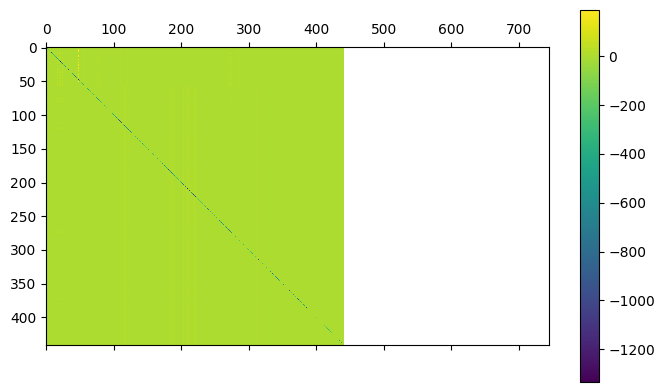

In [27]:
################ Export results
elasticities = results.compute_elasticities()

# Export pyblp results summary as LaTeX-like text
with open('pyblp_results.tex', 'w', encoding='utf-8') as f:
    f.write(str(results))

single_market = df['market_ids'] == 'P01Y2019'
plt.colorbar(plt.matshow(elasticities[single_market]))

In [8]:
################ Load supply-side data
supply_df = pd.read_csv('supply_side_data.csv')

In [ ]:
################ Supply side model

# Create a time trend variable
supply_df['time_trend'] = supply_df['year'].astype(int) - supply_df['year'].astype(int).min() + 1

# Add time_trend
formula = 'log(charging_stations_stock) ~ [log(EV_stock) ~  shift_share_IV] + C(province) + time_trend'

model = IV2SLS.from_formula(formula, data=supply_df).fit(
)
print(model.summary)

                               IV-2SLS Estimation Summary                               
Dep. Variable:     log(charging_stations_stock)   R-squared:                      0.9733
Estimator:                              IV-2SLS   Adj. R-squared:                 0.9663
No. Observations:                           155   F-statistic:                 1.004e+06
Date:                          Wed, Jul 23 2025   P-value (F-stat)                0.0000
Time:                                  15:08:30   Distribution:                 chi2(33)
Cov. Estimator:                          robust                                         
                                                                                        
                                   Parameter Estimates                                   
                       Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------
C(province)[上海市]  

In [38]:
# Run first stage regression
first_stage = IV2SLS.from_formula(
    'log(EV_stock) ~ shift_share_IV',
    data=supply_df
).fit(cov_type='clustered', clusters=supply_df['province'])
print(first_stage.summary)

                            OLS Estimation Summary                            
Dep. Variable:          log(EV_stock)   R-squared:                      0.1264
Estimator:                        OLS   Adj. R-squared:                 0.1207
No. Observations:                 155   F-statistic:                    13.667
Date:                Wed, Jul 23 2025   P-value (F-stat)                0.0002
Time:                        15:06:13   Distribution:                  chi2(1)
Cov. Estimator:             clustered                                         
                                                                              
                               Parameter Estimates                                
                Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
----------------------------------------------------------------------------------
Intercept          11.132     0.3820     29.141     0.0000      10.383      11.880
shift_share_IV  6.003e-13  1.624e-13

In [ ]:
# Export model summary as LaTeX
# Stargazer does not support different covariate orders for each model,
# so the best practice is to include all you want to show and accept blanks for the other.
main_vars = ['Intercept', 'log(EV_stock)', 'time_trend', 'shift_share_IV']

stargazer = Stargazer([model, first_stage])
stargazer.covariate_order(main_vars)

with open('supply_and_first_stage_stargazer.tex', 'w', encoding='utf-8') as f:
    f.write(stargazer.render_latex())
